
=== Comparison SW vs Metropolis ===
L=32, n_therm=500, n_meas=6000, max_lag=400, seeds=(1, 2, 3)



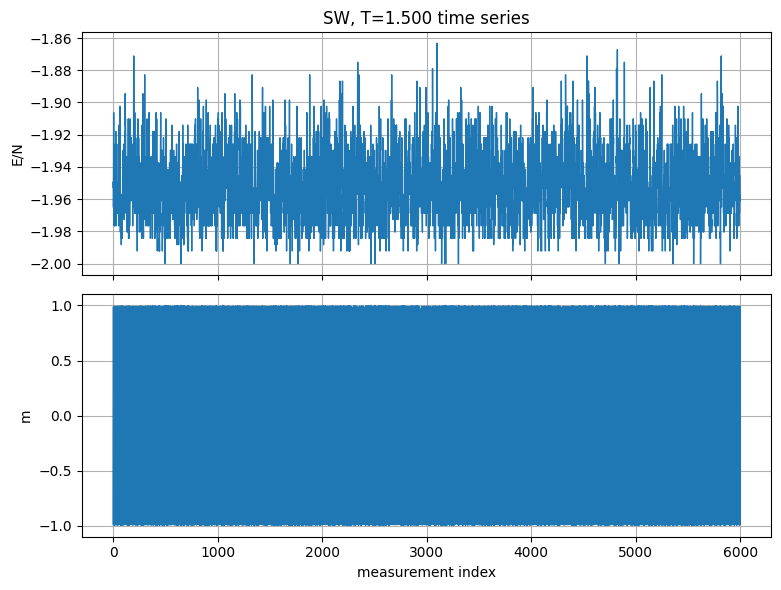

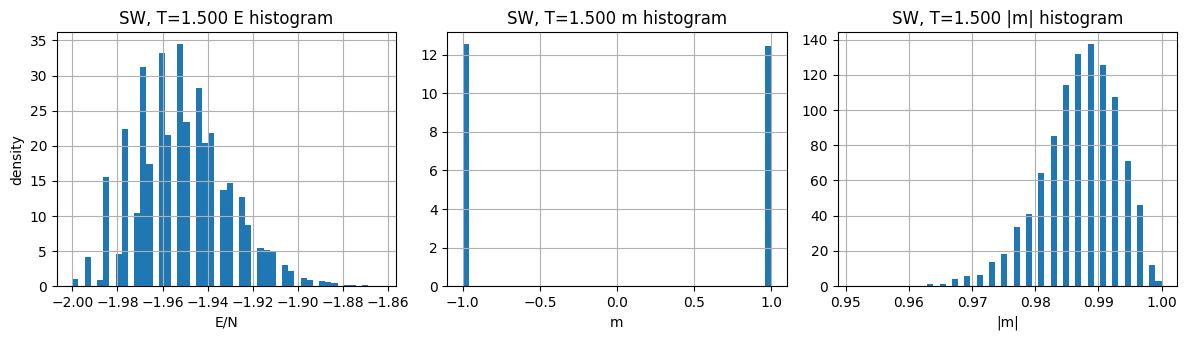

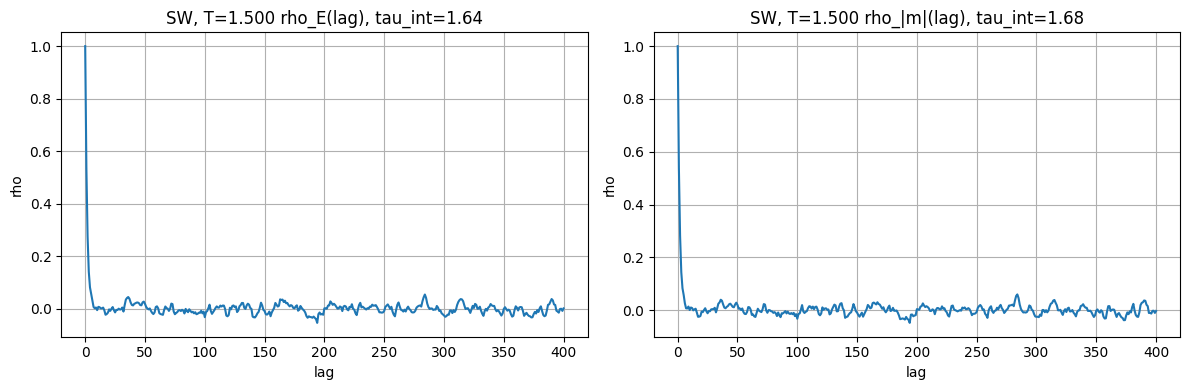

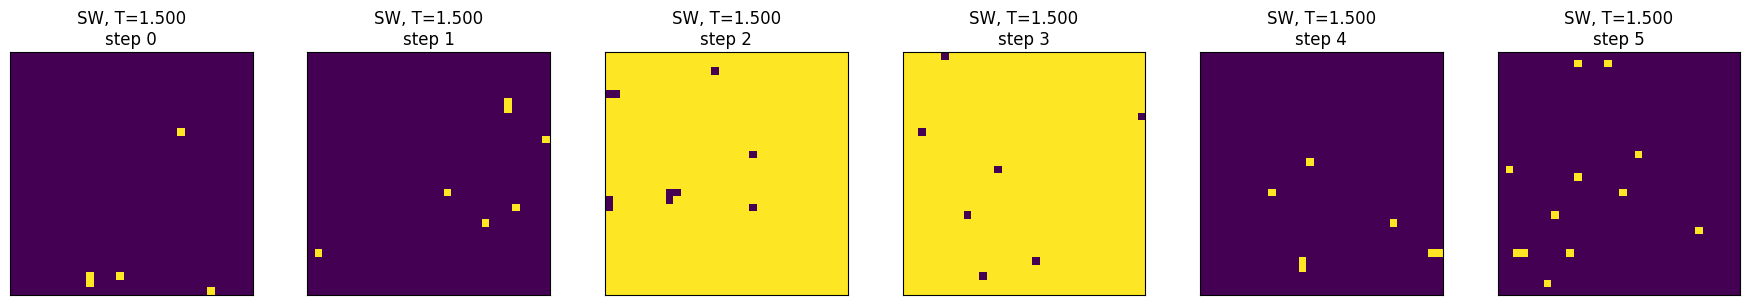

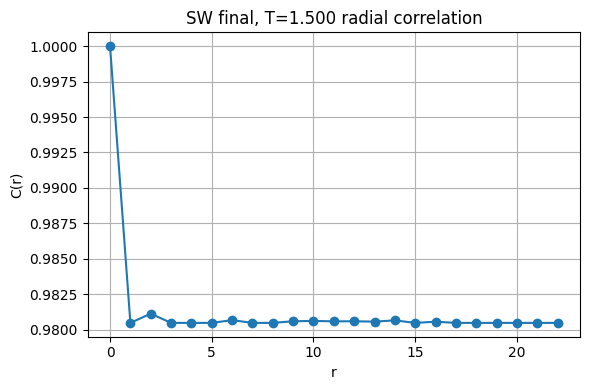

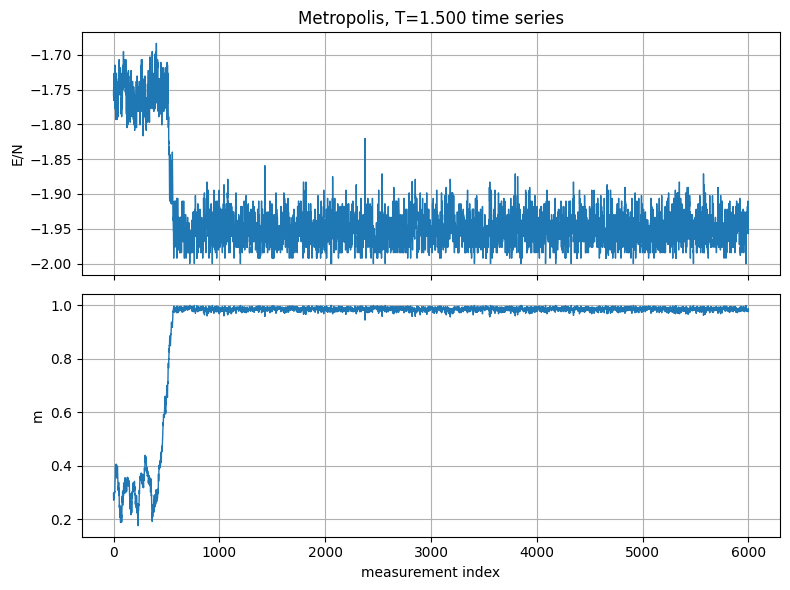

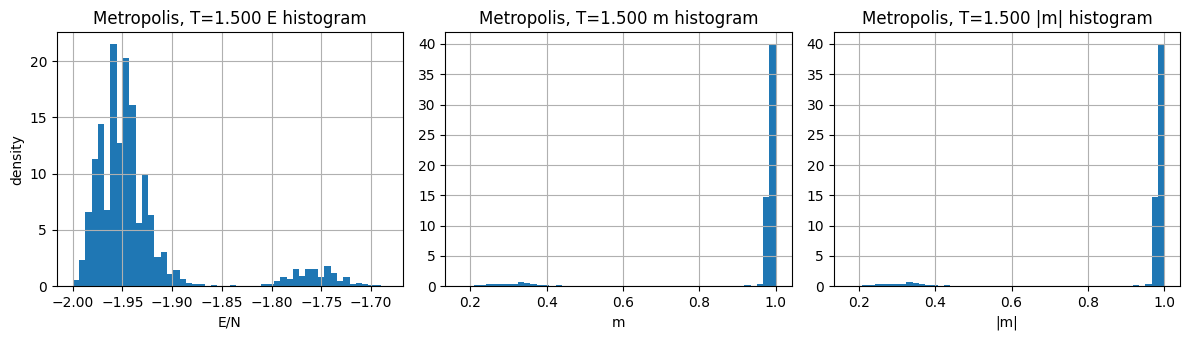

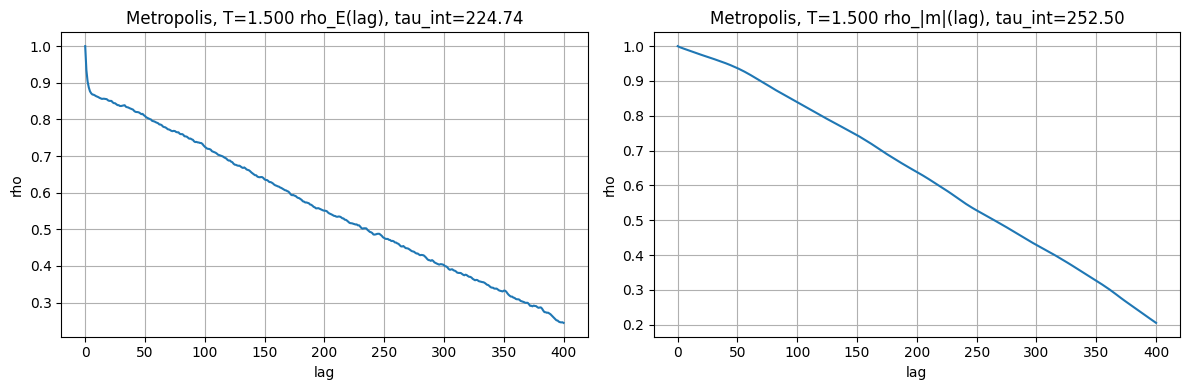

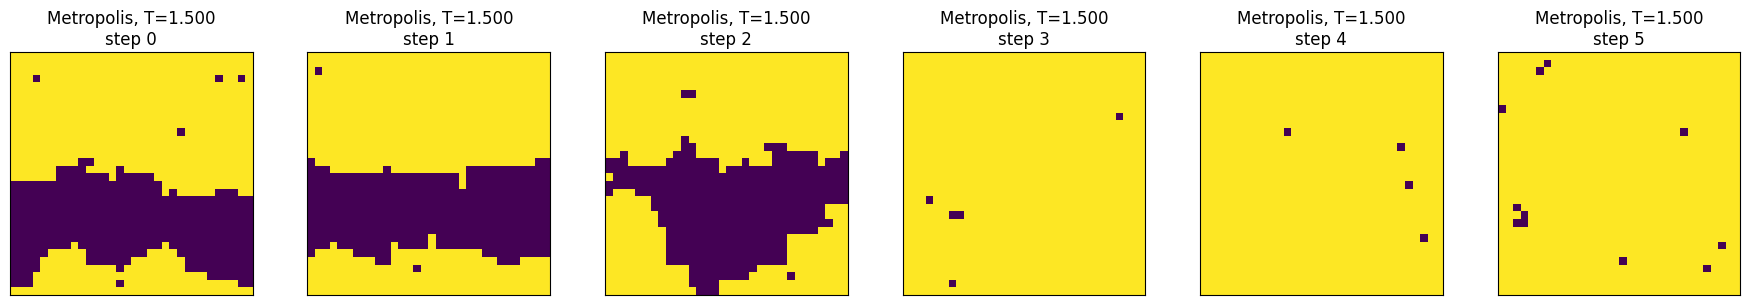

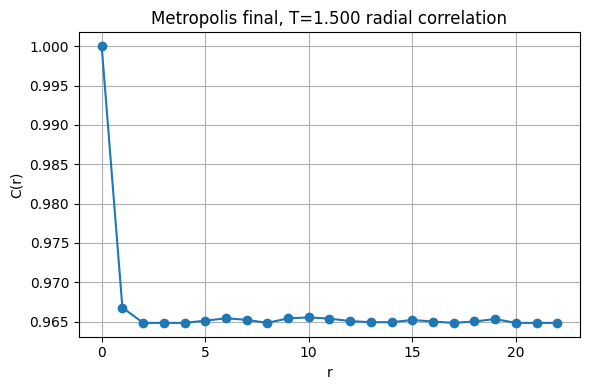

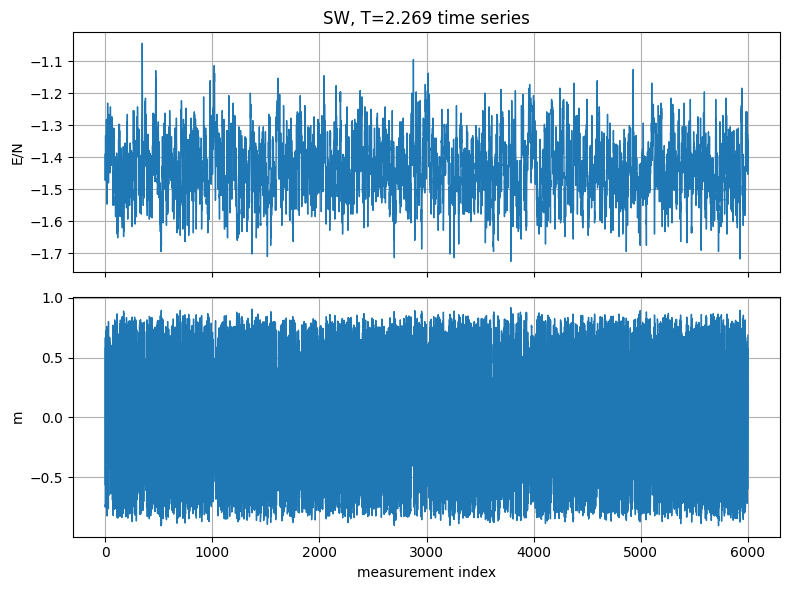

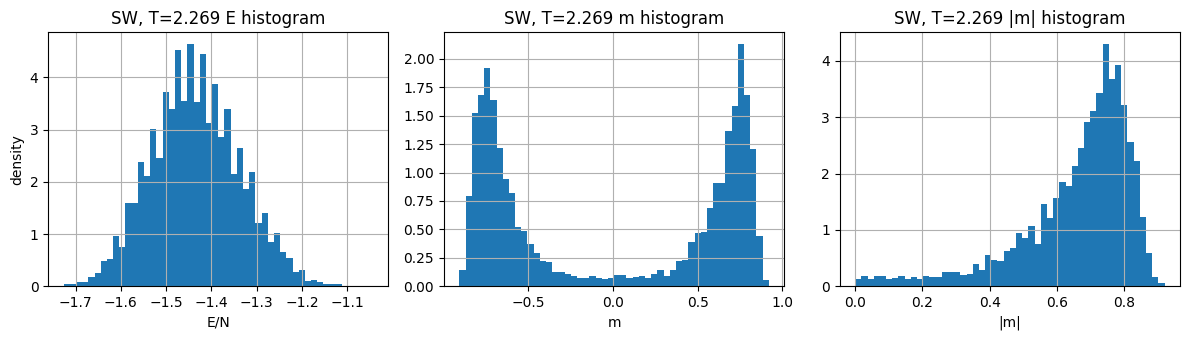

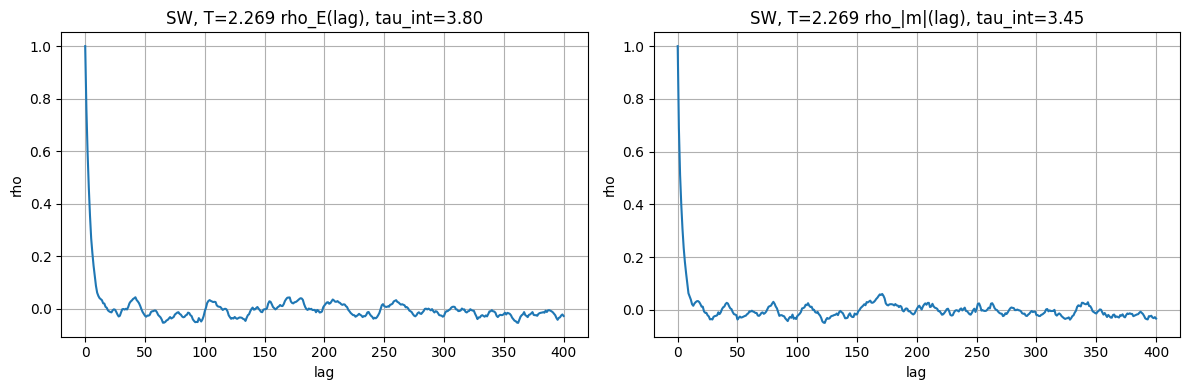

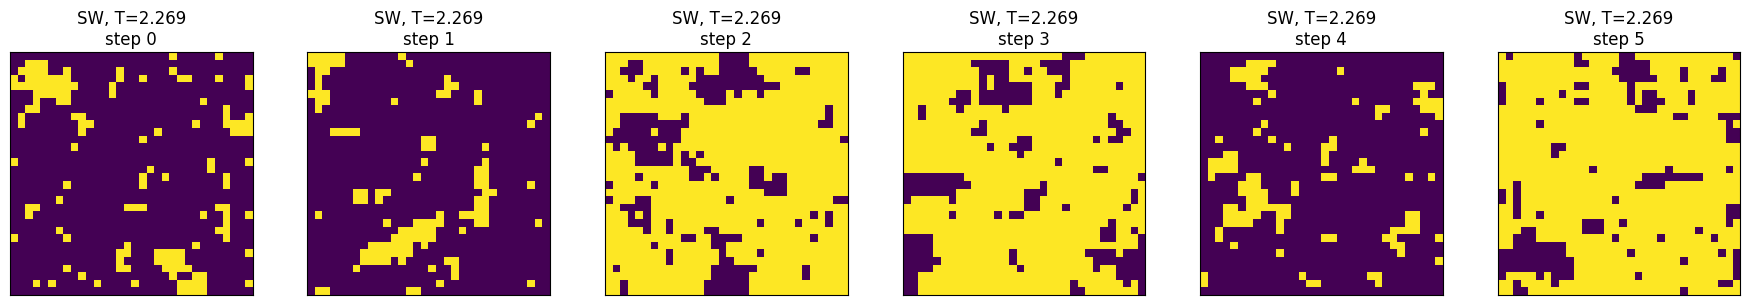

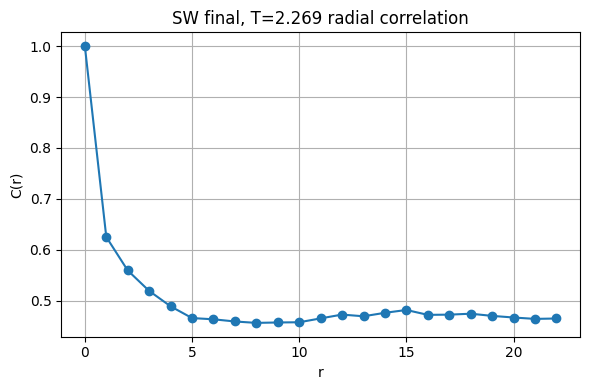

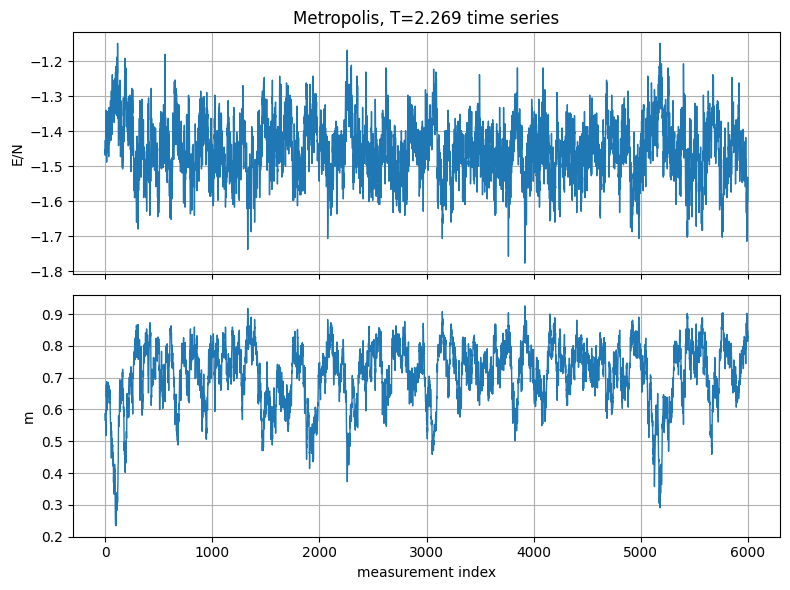

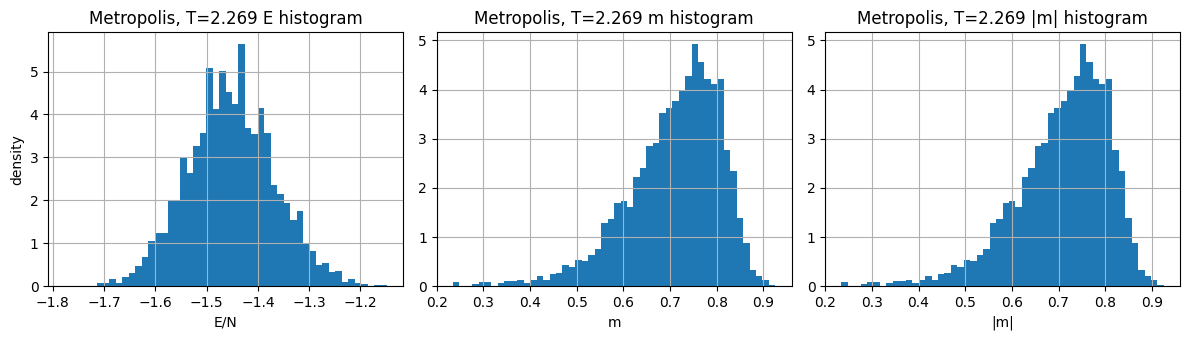

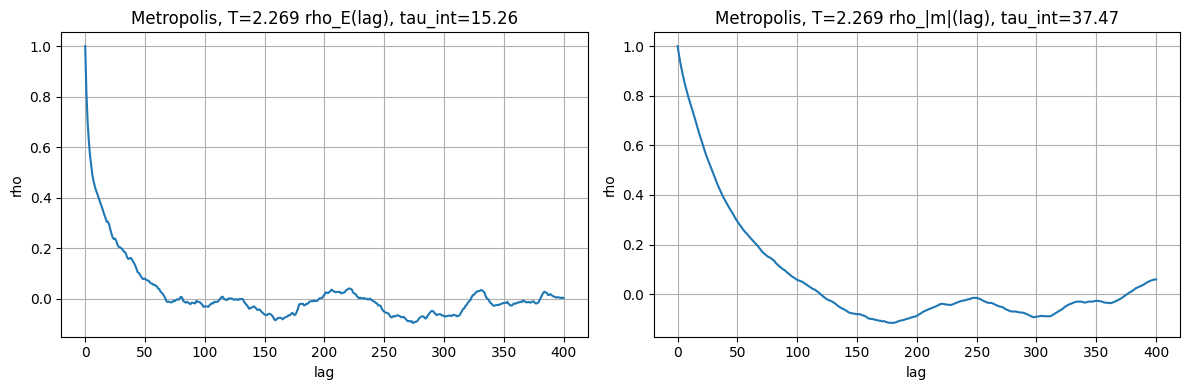

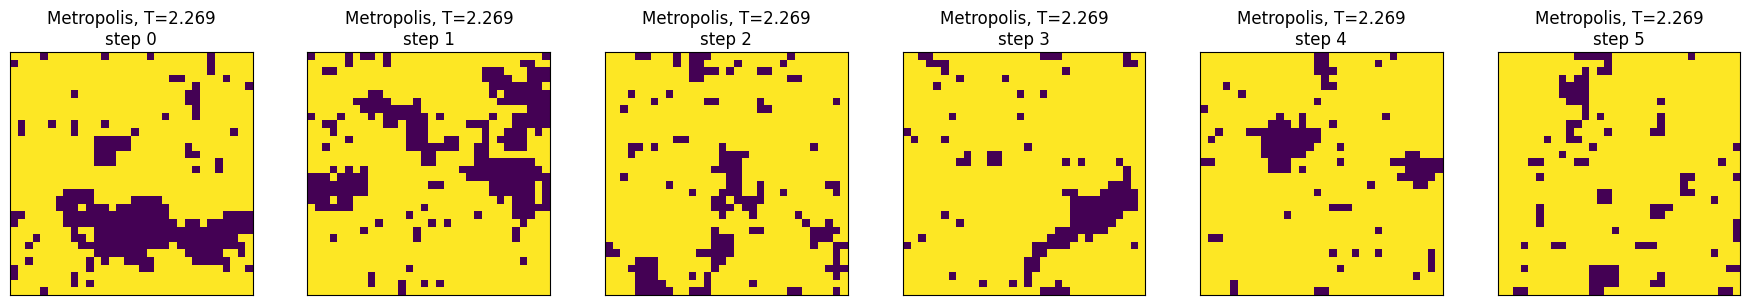

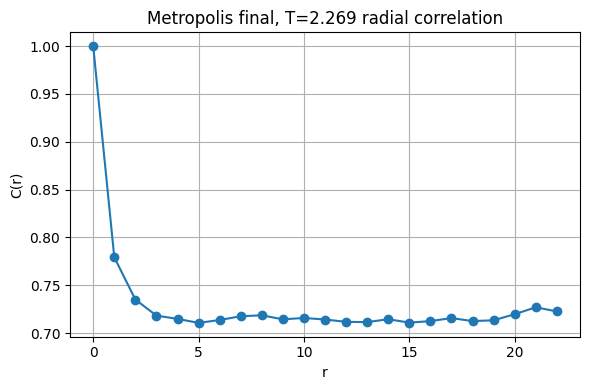

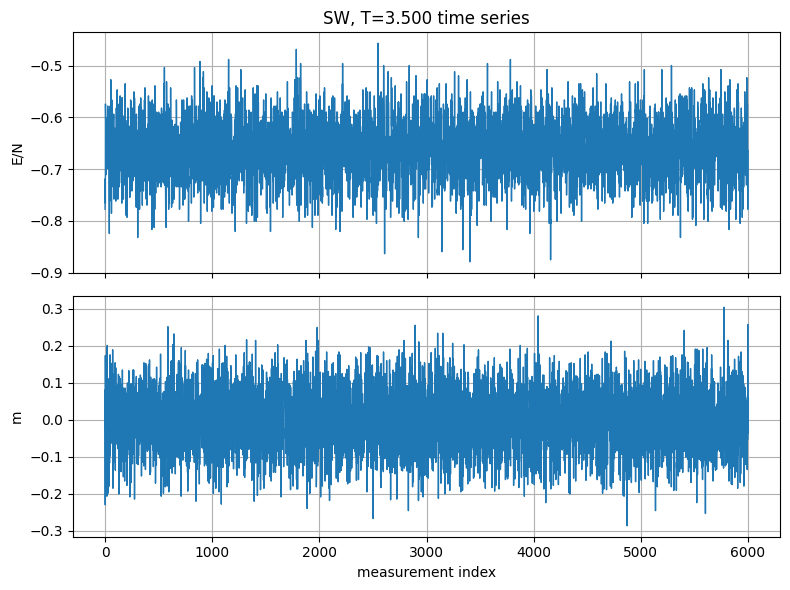

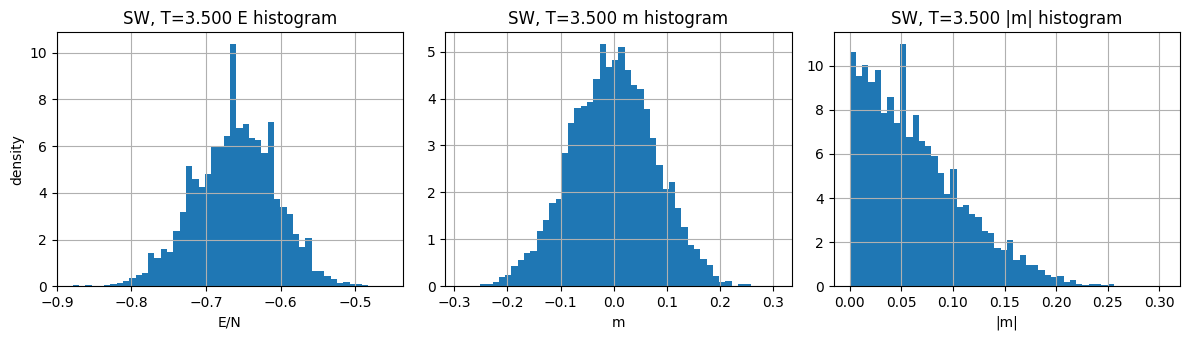

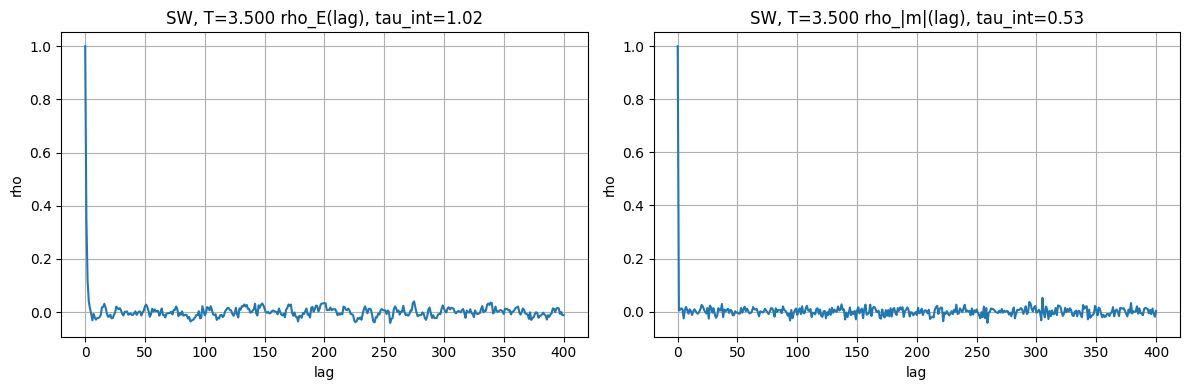

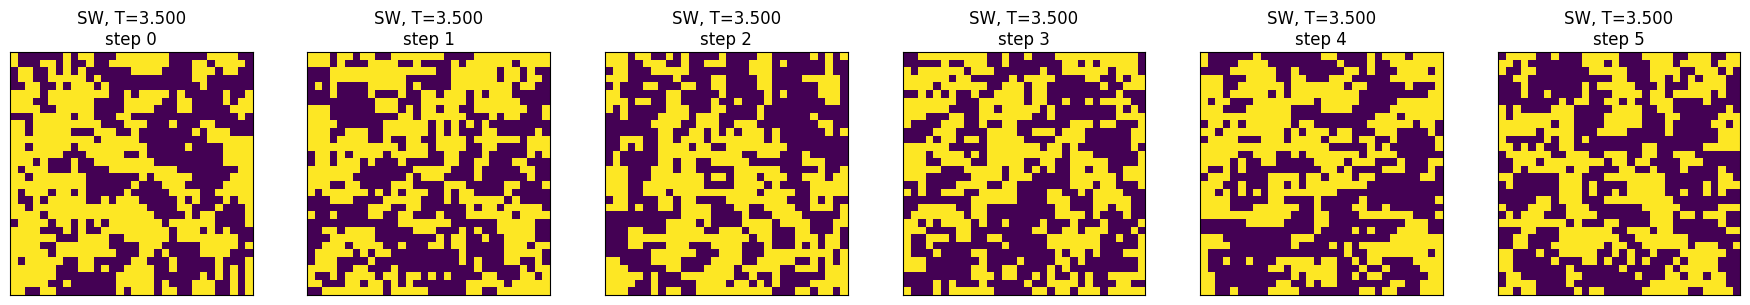

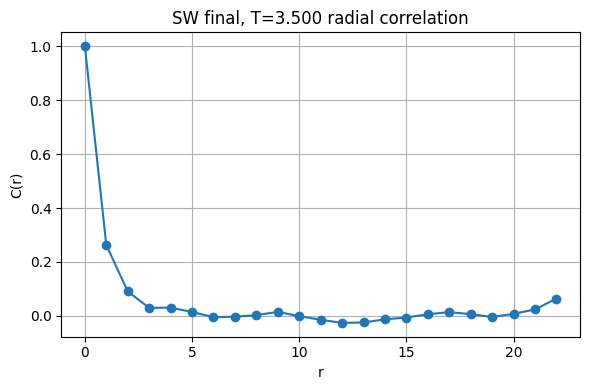

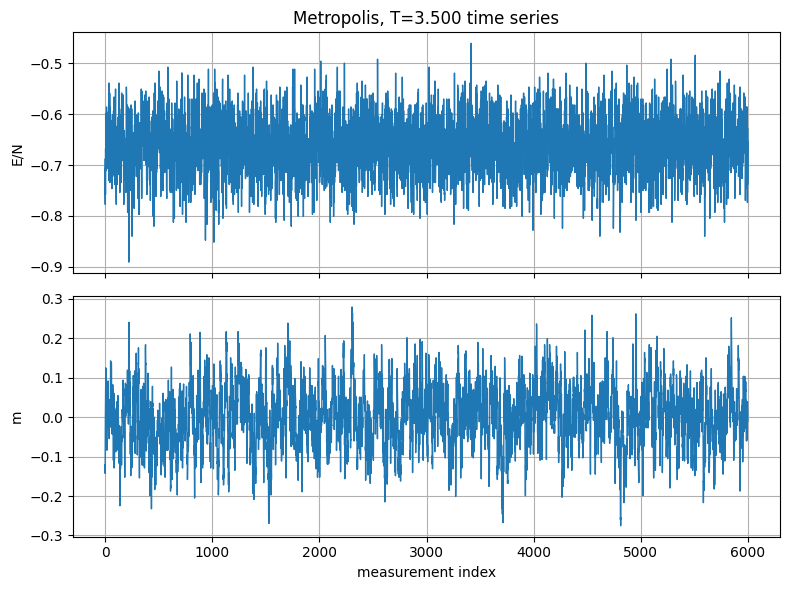

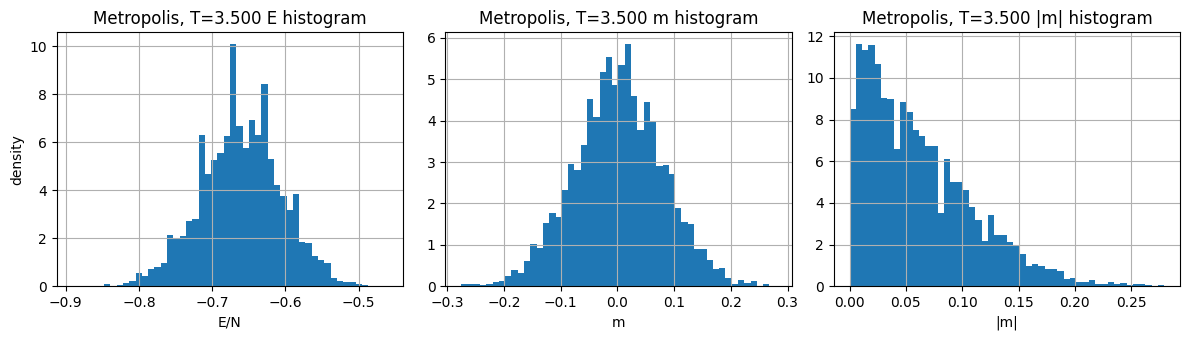

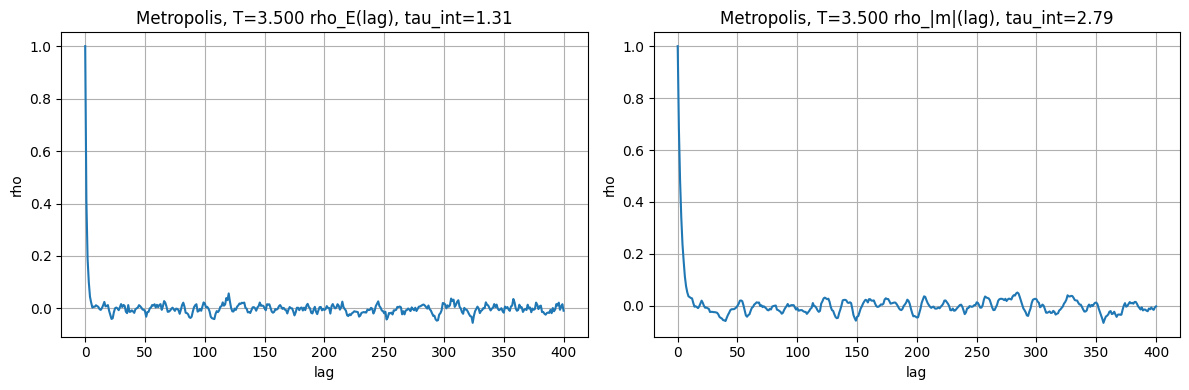

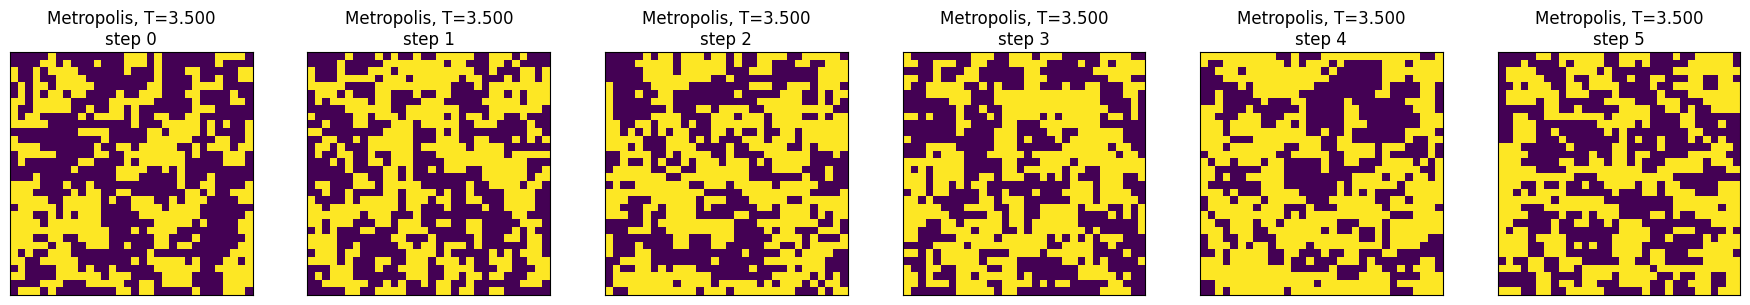

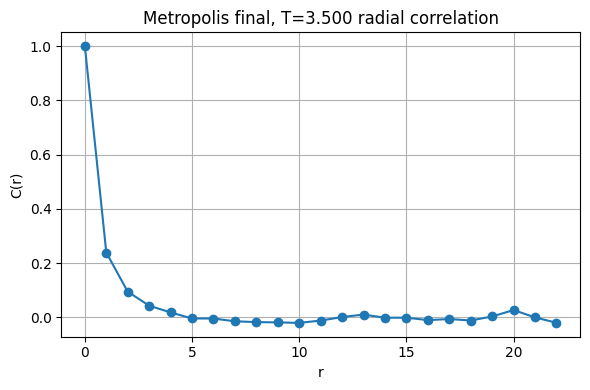

T     seed   <E>_SW    <|m|>_SW  tauE_SW  tau|m|_SW  time_SW   <E>_M     <|m|>_M   tauE_M   tau|m|_M   time_M   acc_M
1.500     1   -1.9514    0.9865     1.64       1.68     1.62   -1.9336    0.9308   224.74     252.50    28.65  0.018
1.500     2   -1.9513    0.9866     1.61       1.62     1.57   -1.9510    0.9865     1.48       1.60    27.74  0.013
1.500     3   -1.9510    0.9865     1.52       1.53     1.51   -1.9511    0.9865     1.54       1.69    27.84  0.013
2.269     1   -1.4354    0.6591     3.80       3.45     1.61   -1.4525    0.7087    15.26      37.47    28.03  0.186
2.269     2   -1.4347    0.6536     4.66       3.68     1.81   -1.4228    0.6419    62.05     175.70    34.42  0.196
2.269     3   -1.4367    0.6605     3.56       3.21     1.75   -1.4365    0.6661    44.90     129.32    36.70  0.191
3.500     1   -0.6612    0.0638     1.02       0.53     1.67   -0.6612    0.0619     1.31       2.79    31.76  0.547
3.500     2   -0.6583    0.0615     0.96       0.62     1.47   

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from ising_core import Ising2D, autocorr_norm, tau_int_from_rho, correlation_map_fft, radial_average_corr


def plot_timeseries(E, M, title_prefix=""):
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axes[0].plot(E, linewidth=1)
    axes[0].set_ylabel("E/N")
    axes[0].grid(True)
    axes[0].set_title(f"{title_prefix} time series")

    axes[1].plot(M, linewidth=1)
    axes[1].set_ylabel("m")
    axes[1].set_xlabel("measurement index")
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()


def plot_histograms(E, M, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].hist(E, bins=50, density=True)
    axes[0].set_xlabel("E/N")
    axes[0].set_ylabel("density")
    axes[0].grid(True)
    axes[0].set_title(f"{title_prefix} E histogram")

    axes[1].hist(M, bins=50, density=True)
    axes[1].set_xlabel("m")
    axes[1].grid(True)
    axes[1].set_title(f"{title_prefix} m histogram")

    axes[2].hist(np.abs(M), bins=50, density=True)
    axes[2].set_xlabel("|m|")
    axes[2].grid(True)
    axes[2].set_title(f"{title_prefix} |m| histogram")

    plt.tight_layout()
    plt.show()


def plot_autocorr(E, M, max_lag, title_prefix=""):
    rhoE = autocorr_norm(E, max_lag)
    rhoAbsM = autocorr_norm(np.abs(M), max_lag)

    tauE = tau_int_from_rho(rhoE)
    tauAbsM = tau_int_from_rho(rhoAbsM)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(rhoE)
    axes[0].set_title(f"{title_prefix} rho_E(lag), tau_int={tauE:.2f}")
    axes[0].set_xlabel("lag")
    axes[0].set_ylabel("rho")
    axes[0].grid(True)

    axes[1].plot(rhoAbsM)
    axes[1].set_title(f"{title_prefix} rho_|m|(lag), tau_int={tauAbsM:.2f}")
    axes[1].set_xlabel("lag")
    axes[1].set_ylabel("rho")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return tauE, tauAbsM


def plot_corr_function(spins_1d, Lx, Ly, title_prefix=""):
    C = correlation_map_fft(spins_1d, Lx, Ly)
    r, Cr = radial_average_corr(C)

    plt.figure(figsize=(6, 4))
    plt.plot(r, Cr, marker="o")
    plt.xlabel("r")
    plt.ylabel("C(r)")
    plt.title(f"{title_prefix} radial correlation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_snapshots(configs, Lx, Ly, title_prefix=""):
    # show up to 6 snapshots
    n = min(len(configs), 6)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]
    for k in range(n):
        axes[k].imshow(configs[k].reshape(Lx, Ly), vmin=-1, vmax=1, interpolation="nearest")
        axes[k].set_title(f"{title_prefix}\nstep {k}")
        axes[k].set_xticks([])
        axes[k].set_yticks([])
    plt.tight_layout()
    plt.show()


def compare_algorithms(L=32, temps=(1.5, 2.269, 3.5), seeds=(1, 2, 3),
                       n_therm=500, n_meas=6000, max_lag=400):
    """
    Runs SW and Metropolis for several temps and several seeds.
    Prints summary table and makes key plots for the first seed.
    """
    print("\n=== Comparison SW vs Metropolis ===")
    print(f"L={L}, n_therm={n_therm}, n_meas={n_meas}, max_lag={max_lag}, seeds={seeds}\n")

    rows = []
    for T in temps:
        for seed in seeds:
            # SW
            model_sw = Ising2D(L, L, J=1.0, h=0.0, kB=1.0, seed=seed)
            t0 = time.perf_counter()
            E_sw, M_sw, _, cfg_sw = model_sw.run("sw", T, n_therm, n_meas, stride=1,
                                                 record_configs=(seed == seeds[0]), config_every=200)
            t_sw = time.perf_counter() - t0

            tauE_sw = tau_int_from_rho(autocorr_norm(E_sw, max_lag))
            tauAbsM_sw = tau_int_from_rho(autocorr_norm(np.abs(M_sw), max_lag))

            # Metropolis
            model_me = Ising2D(L, L, J=1.0, h=0.0, kB=1.0, seed=seed)
            t0 = time.perf_counter()
            E_me, M_me, acc_me, cfg_me = model_me.run("metropolis", T, n_therm, n_meas, stride=1,
                                                      record_configs=(seed == seeds[0]), config_every=200)
            t_me = time.perf_counter() - t0

            tauE_me = tau_int_from_rho(autocorr_norm(E_me, max_lag))
            tauAbsM_me = tau_int_from_rho(autocorr_norm(np.abs(M_me), max_lag))

            rows.append((T, seed,
                         E_sw.mean(), np.abs(M_sw).mean(), tauE_sw, tauAbsM_sw, t_sw,
                         E_me.mean(), np.abs(M_me).mean(), tauE_me, tauAbsM_me, t_me,
                         float(np.mean(acc_me)) if acc_me is not None else np.nan))

            # plots only for first seed (to not spam)
            if seed == seeds[0]:
                # timeseries + hist + autocorr
                plot_timeseries(E_sw, M_sw, title_prefix=f"SW, T={T:.3f}")
                plot_histograms(E_sw, M_sw, title_prefix=f"SW, T={T:.3f}")
                plot_autocorr(E_sw, M_sw, max_lag=max_lag, title_prefix=f"SW, T={T:.3f}")
                plot_snapshots(cfg_sw, L, L, title_prefix=f"SW, T={T:.3f}")
                plot_corr_function(model_sw.spins, L, L, title_prefix=f"SW final, T={T:.3f}")

                plot_timeseries(E_me, M_me, title_prefix=f"Metropolis, T={T:.3f}")
                plot_histograms(E_me, M_me, title_prefix=f"Metropolis, T={T:.3f}")
                plot_autocorr(E_me, M_me, max_lag=max_lag, title_prefix=f"Metropolis, T={T:.3f}")
                plot_snapshots(cfg_me, L, L, title_prefix=f"Metropolis, T={T:.3f}")
                plot_corr_function(model_me.spins, L, L, title_prefix=f"Metropolis final, T={T:.3f}")

    # Print summary table
    print("T     seed   <E>_SW    <|m|>_SW  tauE_SW  tau|m|_SW  time_SW   <E>_M     <|m|>_M   tauE_M   tau|m|_M   time_M   acc_M")
    for r in rows:
        (T, seed,
         E_sw_m, absM_sw_m, tauE_sw, tauAbsM_sw, t_sw,
         E_me_m, absM_me_m, tauE_me, tauAbsM_me, t_me,
         acc_m) = r
        print(f"{T:4.3f} {seed:5d} {E_sw_m:9.4f} {absM_sw_m:9.4f} {tauE_sw:8.2f} {tauAbsM_sw:10.2f} {t_sw:8.2f} "
              f"{E_me_m:9.4f} {absM_me_m:9.4f} {tauE_me:8.2f} {tauAbsM_me:10.2f} {t_me:8.2f} {acc_m:6.3f}")

    return rows


def scaling_at_Tc(Ls=(16, 32, 64), Tc=2.269, seed=1,
                  n_therm=800, n_meas=12000, max_lag=600):
    """
    Scaling study: tau_int(E) vs L at T=Tc for SW and Metropolis.
    Produces linear and log-log plots, and a simple power-law fit.
    """
    tau_sw = []
    tau_me = []

    for L in Ls:
        # SW
        sw = Ising2D(L, L, J=1.0, h=0.0, kB=1.0, seed=seed)
        E_sw, M_sw, _, _ = sw.run("sw", Tc, n_therm, n_meas)
        tauE_sw = tau_int_from_rho(autocorr_norm(E_sw, max_lag))
        tau_sw.append(tauE_sw)

        # Metropolis
        me = Ising2D(L, L, J=1.0, h=0.0, kB=1.0, seed=seed)
        E_me, M_me, _, _ = me.run("metropolis", Tc, n_therm, n_meas)
        tauE_me = tau_int_from_rho(autocorr_norm(E_me, max_lag))
        tau_me.append(tauE_me)

        print(f"L={L}: tauE SW={tauE_sw:.2f}, Metropolis={tauE_me:.2f}")

    Ls = np.array(Ls, dtype=float)
    tau_sw = np.array(tau_sw, dtype=float)
    tau_me = np.array(tau_me, dtype=float)

    plt.figure(figsize=(6, 4))
    plt.plot(Ls, tau_sw, marker="o", label="SW")
    plt.plot(Ls, tau_me, marker="o", label="Metropolis")
    plt.xlabel("L")
    plt.ylabel("tau_int(E)")
    plt.title("Scaling of tau_int(E) at Tc")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.loglog(Ls, tau_sw, marker="o", label="SW")
    plt.loglog(Ls, tau_me, marker="o", label="Metropolis")
    plt.xlabel("L")
    plt.ylabel("tau_int(E)")
    plt.title("log-log scaling at Tc")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # power-law fit: log(tau) = a + z log(L)
    def fit_z(L, tau):
        x = np.log(L)
        y = np.log(tau)
        A = np.vstack([np.ones_like(x), x]).T
        coeff, *_ = np.linalg.lstsq(A, y, rcond=None)
        a, z = coeff[0], coeff[1]
        return float(z), float(np.exp(a))

    z_sw, a_sw = fit_z(Ls, tau_sw)
    z_me, a_me = fit_z(Ls, tau_me)
    print(f"\nFit tau ~ a L^z at Tc:")
    print(f"  SW:         z = {z_sw:.3f}, a = {a_sw:.3f}")
    print(f"  Metropolis: z = {z_me:.3f}, a = {a_me:.3f}")


if __name__ == "__main__":
    # 1) Main comparison (with multiple seeds)
    compare_algorithms(
        L=32,
        temps=(1.5, 2.269, 3.5),
        seeds=(1, 2, 3),
        n_therm=500,
        n_meas=6000,
        max_lag=400
    )

    # 2) Scaling at Tc
    scaling_at_Tc(
        Ls=(16, 32, 64),
        Tc=2.269,
        seed=1,
        n_therm=800,
        n_meas=12000,
        max_lag=600
    )